[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aaniya22/ML-CaPsule/blob/wildfire-survival-prediction/Wildfire_Survival_Prediction/notebooks/01_eda.ipynb)

## Wildfire Survival Prediction — EDA & Approach

This notebook explores the wildfire event dataset and lays the groundwork for predicting 
how long/how far a wildfire will "survive" or spread.

**Target variable:** e.g. `num_perimeters_0_5h` or whatever column represents spread/survival
**Key features:** temporal features like `dt_first_last_0_5h`, `low_temporal_re...` (fill in real names)
**Approach:** We first explore feature distributions and correlations, then engineer features 
that capture fire growth rate in early time windows, which will feed into the prediction model 
in later notebooks.

### Load the Data
We load the training set, test set, and event metadata files. `train` and `test` contain 
per-event fire spread records, while `meta` holds supplementary event-level information 
(e.g. location, ignition details) that we'll join in during feature engineering.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset from GitHub Gist
train = pd.read_csv("https://gist.githubusercontent.com/aaniya22/6dc5b5551cedb694667959e21a249f00/raw/46d89936c8d98d7b9c39cbed9b133bc859f809a2/train.csv")
test = pd.read_csv("https://gist.githubusercontent.com/aaniya22/6dc5b5551cedb694667959e21a249f00/raw/46d89936c8d98d7b9c39cbed9b133bc859f809a2/test.csv")
meta = pd.read_csv("https://gist.githubusercontent.com/aaniya22/6dc5b5551cedb694667959e21a249f00/raw/46d89936c8d98d7b9c39cbed9b133bc859f809a2/metaData.csv")

train.head()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0


### Initial Inspection
A quick check of the dataset dimensions and column names to understand the scope of data 
we're working with before deeper analysis.

In [31]:
# Print dataset dimensions and full column list
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nColumns:")
print(train.columns.tolist())

Train shape: (221, 37)
Test shape: (95, 35)

Columns:
['event_id', 'num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h', 'area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first', 'log1p_growth', 'log_area_ratio_0_5h', 'relative_growth_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'centroid_displacement_m', 'centroid_speed_m_per_h', 'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos', 'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h', 'dist_slope_ci_0_5h', 'closing_speed_m_per_h', 'closing_speed_abs_m_per_h', 'projected_advance_m', 'dist_accel_m_per_h2', 'dist_fit_r2_0_5h', 'alignment_cos', 'alignment_abs', 'cross_track_component', 'along_track_speed', 'event_start_hour', 'event_start_dayofweek', 'event_start_month', 'time_to_hit_hours', 'event']


### List All Columns
Printing every column with its index makes it easier to reference specific features 
by name later when selecting inputs for the model.

In [32]:
# Print each column name with its index for easy reference later
for i, col in enumerate(train.columns):
    print(i, col)

0 event_id
1 num_perimeters_0_5h
2 dt_first_last_0_5h
3 low_temporal_resolution_0_5h
4 area_first_ha
5 area_growth_abs_0_5h
6 area_growth_rel_0_5h
7 area_growth_rate_ha_per_h
8 log1p_area_first
9 log1p_growth
10 log_area_ratio_0_5h
11 relative_growth_0_5h
12 radial_growth_m
13 radial_growth_rate_m_per_h
14 centroid_displacement_m
15 centroid_speed_m_per_h
16 spread_bearing_deg
17 spread_bearing_sin
18 spread_bearing_cos
19 dist_min_ci_0_5h
20 dist_std_ci_0_5h
21 dist_change_ci_0_5h
22 dist_slope_ci_0_5h
23 closing_speed_m_per_h
24 closing_speed_abs_m_per_h
25 projected_advance_m
26 dist_accel_m_per_h2
27 dist_fit_r2_0_5h
28 alignment_cos
29 alignment_abs
30 cross_track_component
31 along_track_speed
32 event_start_hour
33 event_start_dayofweek
34 event_start_month
35 time_to_hit_hours
36 event


### Remaining Feature Columns
Continuing to list the later columns, which include derived/engineered features like 
projected advance and directional alignment — likely computed upstream and useful for modeling.

In [33]:
# Continue listing columns 25 through 32
for col in train.columns[25:33]:
    print(col)

projected_advance_m
dist_accel_m_per_h2
dist_fit_r2_0_5h
alignment_cos
alignment_abs
cross_track_component
along_track_speed
event_start_hour


### Missing Values & Target Distribution
We check for missing data across columns, then look at the distribution of the `event` 
(censoring) column and summarize `time_to_hit_hours`, since these relate directly to what 
we're trying to predict — how a fire event progresses and whether it's fully observed.

In [34]:
# Show only columns that actually have missing values
print("Missing values per column:\n", train.isnull().sum()[train.isnull().sum() > 0])
# Check class balance of the event (censoring) column
print("\nEvent (censoring) distribution:")
print(train['event'].value_counts())
# Summary stats for the target variable
print("\ntime_to_hit_hours summary:")
print(train['time_to_hit_hours'].describe())

Missing values per column:
 Series([], dtype: int64)

Event (censoring) distribution:
event
0    152
1     69
Name: count, dtype: int64

time_to_hit_hours summary:
count    221.000000
mean      37.567626
std       25.902361
min        0.001220
25%       12.242322
50%       43.109830
75%       63.938706
max       66.994474
Name: time_to_hit_hours, dtype: float64


### Target Variable Visualizations
We visualize the distribution of `time_to_hit_hours` split by censoring status, and the 
overall balance between hit vs. censored events. Understanding this distribution is key 
since it directly shapes how we frame the prediction problem (e.g. survival analysis vs. 
straightforward regression/classification).

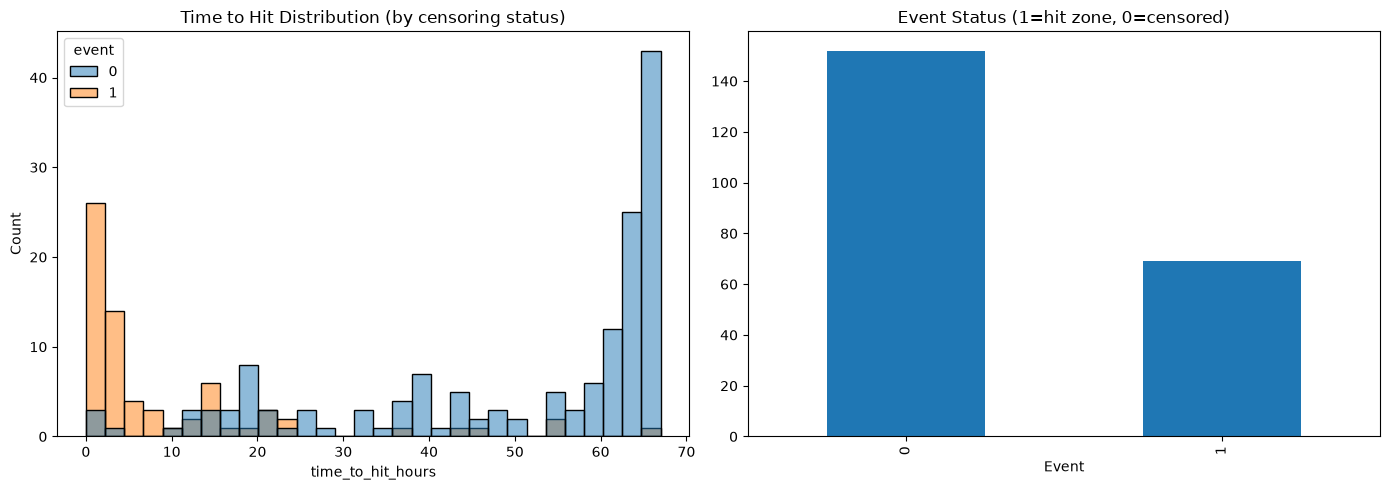

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of time_to_hit_hours by event status
sns.histplot(data=train, x='time_to_hit_hours', hue='event', bins=30, ax=axes[0])
axes[0].set_title('Time to Hit Distribution (by censoring status)')

# Event distribution
train['event'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Event Status (1=hit zone, 0=censored)')
axes[1].set_xlabel('Event')

plt.tight_layout()
plt.show()

### Correlation Heatmap: Key Fire Behavior Features
We select the most relevant fire-behavior features and examine how strongly they correlate 
with each other and with `time_to_hit_hours`/`event`. Highly correlated features may be 
redundant, while features strongly correlated with the target are strong candidates for 
the prediction model.

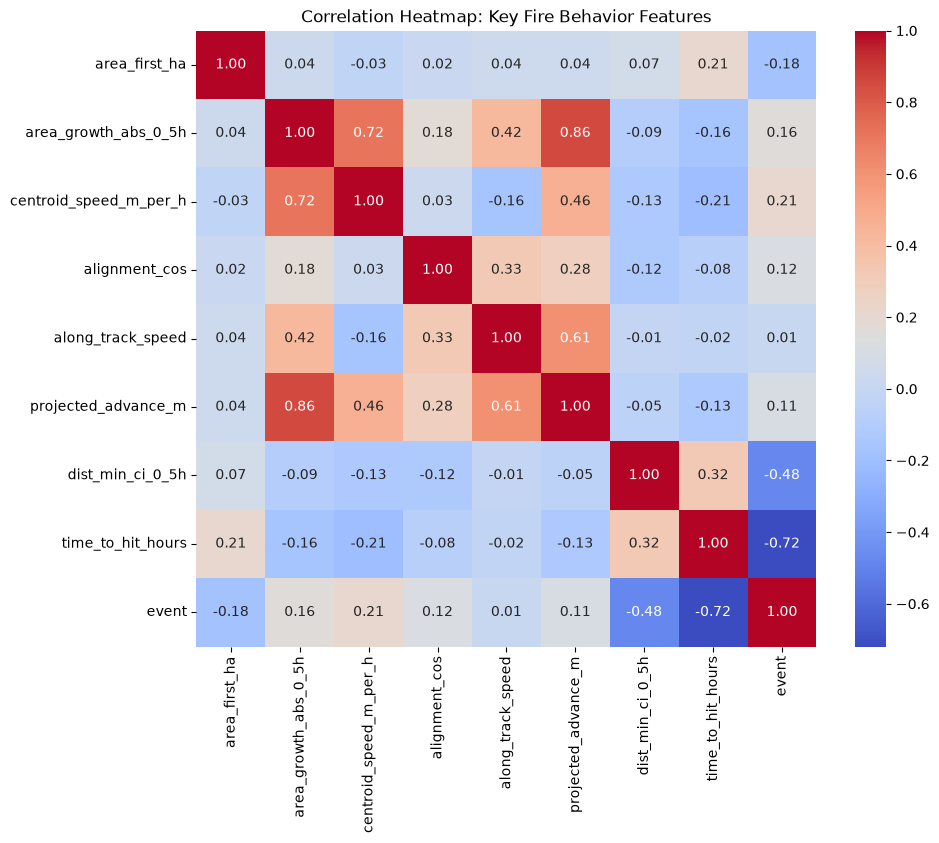

In [36]:
# Select key fire-behavior features relevant to spread/survival
key_cols = ['area_first_ha', 'area_growth_abs_0_5h', 'centroid_speed_m_per_h',
            'alignment_cos', 'along_track_speed', 'projected_advance_m',
            'dist_min_ci_0_5h', 'time_to_hit_hours', 'event']

# Plot correlation matrix to spot redundant/predictive features
plt.figure(figsize=(10, 8))
sns.heatmap(train[key_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Key Fire Behavior Features')
plt.show()